In [3]:
import matplotlib.pyplot as plt
import skimage
import os
from PIL import Image
import numpy as np
import random
from skimage.filters import threshold_otsu, threshold_local
from skimage.color import rgb2gray
import pandas as pd
import seaborn as sns

Celem projektu była klasteryzacja zdjęć meduz, ale jako że poszczególne gatunki meduz były pogrupowane w folderach, to naszym celem było jak najlepiej dopasować różne gatunki do różnych klastrów.

In [9]:
# Wczytanie embeddingow dotyczących obrazów meduz, nie dzielimy na train test ponieważ mamy klasteryzacje hierarhiczną która nie posiada możliwości predykcji nauczonego modelu.
df = pd.read_csv(r"..\new_data\features\all_features.csv")

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,label
0,-1.373664,1.130364,-0.520588,4.582074,-0.159933,9.143056,3.106021,2.119004,-0.054013,0.694919,...,-0.876938,0.887230,-0.094019,-0.024968,0.095284,0.244187,0.350245,0.210640,1.554379,mauve_stinger_jellyfish
1,13.364777,-5.331644,-3.598441,-2.249417,-0.513537,-0.061283,1.055907,-0.676633,1.171130,1.635082,...,-0.007140,-0.639098,-0.400543,-0.265316,0.035458,0.124018,0.303183,0.501342,0.172082,Moon_jellyfish
2,-3.981953,6.953153,3.053556,3.013793,-1.034595,2.867479,1.812632,0.971933,1.449355,-2.294751,...,-1.051667,-0.951710,0.332236,0.495268,-0.156602,0.460459,-0.996832,0.331958,-0.440334,lions_mane_jellyfish
3,-8.202881,0.651448,-3.180416,1.728923,1.291359,0.615133,3.203552,-3.994086,4.363211,-5.339526,...,-0.489593,0.046318,0.109930,-0.314843,0.082707,0.628356,-0.128029,-0.012842,0.113241,barrel_jellyfish
4,1.222715,2.002072,-1.427441,-3.035015,4.483143,-5.553167,1.265576,3.747058,-3.158608,-1.933924,...,-0.437370,0.074649,-0.154368,0.082075,0.378330,-0.485364,0.880461,-0.184784,-0.043360,compass_jellyfish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,-0.949504,-7.158218,-1.507189,-1.693069,-3.495238,-2.511450,5.074431,1.370732,6.902033,-1.503647,...,0.334268,-0.430193,0.656089,-0.627273,0.527458,-0.224733,-0.353620,0.002929,0.029773,lions_mane_jellyfish
975,-2.441665,-1.903469,-0.496063,2.540545,3.435913,5.259140,-1.624611,1.415278,-3.909711,-1.879944,...,-0.502198,-0.058826,0.353578,-0.427912,-0.401634,0.220697,0.498131,-0.913368,-0.048718,compass_jellyfish
976,2.970256,0.168088,3.205246,1.654348,3.369863,1.200398,-3.589286,-1.088812,-5.687056,-2.918817,...,1.649229,-0.504858,-0.017761,-0.278821,-0.353828,0.476544,0.966958,-0.279218,0.093379,blue_jellyfish
977,8.168258,-2.942810,-0.115453,1.627771,-1.106622,-7.429671,-1.450931,0.698465,-2.531385,3.971310,...,-0.989936,0.284967,-0.449238,-0.708116,-0.439643,-0.387548,-0.502036,-0.348488,-0.465440,Moon_jellyfish


In [172]:
###Funkcja do tworzenia wykresu rozkładu gatunków w klastrach
def confusion_matrix(y_pred, algorythim_name,df=df):
    contingency_matrix = pd.crosstab(df['label'], y_pred)

    contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100

    annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        contingency_pct,
        annot=annot_pct,       
        fmt="",                
        cmap="Blues",
        cbar_kws={"label": "Percent (%)"}
    )
    plt.title(f"Rozkład gatunków w {len(np.unique(y_pred))} klastrach {algorythim_name} (row‐wise %)")
    plt.xlabel("Cluster")
    plt.ylabel("True Label (gatunek)")
    plt.tight_layout()
    plt.show()

In [173]:
from sklearn.metrics import adjusted_rand_score, v_measure_score, normalized_mutual_info_score, homogeneity_score, completeness_score, fowlkes_mallows_score
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

#Funkcja do obliczania metryk klastrowania
def metrics(true, pred, df_embeddings=df):
    print("Adjusted Rand Index (ARI):", adjusted_rand_score(true, pred))
    print("V-measure:", v_measure_score(true, pred))
    print("NMI:", normalized_mutual_info_score(true, pred))
    print("Homogeneity:", homogeneity_score(true, pred))
    print("Completeness:", completeness_score(true, pred))
    print("Fowlkes-Mallows Score:", fowlkes_mallows_score(true, pred))
    print("-------------------------------------------------")
    print("Silhouette Score:", silhouette_score(df_embeddings.drop(columns=['label']), pred))
    print("Davies-Bouldin Index:", davies_bouldin_score(df_embeddings.drop(columns=['label']), pred))
    print("Calinski-Harabasz Score:", calinski_harabasz_score(df_embeddings.drop(columns=['label']), pred))

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.manifold import TSNE
# Funkcja do generowania wykresu t-SNE dla klastrów
def plot_tsne_clusters(y_pred, algorythm_name, n_clusters=4,df_embeddings=df ,random_state=42, figsize=(8, 6), point_size=30):
    """
    Wygeneruj wykres t-SNE dla podanych embeddingów i etykiet klastrów.

    Parametry:
    ----------
    df_embeddings : pandas.DataFrame
        DataFrame zawierający kolumny embeddingów (np. wektory z ResNet). 
        Jeśli w DataFrame jest kolumna o nazwie 'label', zostanie ona automatycznie pominięta.
    y_pred : array-like (n_samples,)
        Tablica przewidzianych etykiet klastrów (wartości od 0 do n_clusters-1).
    n_clusters : int, opcjonalnie (domyślnie 4)
        Liczba klastrów (używana do wygenerowania odpowiedniej mapy kolorów).
    random_state : int, opcjonalnie (domyślnie 42)
        Ziarno losowości używane w TSNE, dla powtarzalności wyników.
    figsize : tuple, opcjonalnie (domyślnie (8, 6))
        Rozmiar figury w calach (szerokość, wysokość).
    point_size : int lub float, opcjonalnie (domyślnie 30)
        Rozmiar punktów na wykresie.

    Zwraca:
    -------
    None
        Funkcja jedynie wyświetla wykres; nie zwraca wartości.
    """

    if 'label' in df_embeddings.columns:
        X = df_embeddings.drop(columns=['label']).values
    else:
        X = df_embeddings

    tsne = TSNE(n_components=2, random_state=random_state)
    X_2d = tsne.fit_transform(X)

    base_cmap = plt.get_cmap('tab10')
    if n_clusters <= 10:
        colors = [base_cmap(i) for i in range(n_clusters)]
    else:
        colors = [base_cmap(i % 10) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    norm = BoundaryNorm(boundaries=np.arange(-0.5, n_clusters, 1), ncolors=cmap.N)

    plt.figure(figsize=figsize)
    sc = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_pred,
        cmap=cmap,
        norm=norm,
        s=point_size,
        edgecolor='k',
        linewidth=0.2
    )

    plt.title(f"t-SNE {algorythm_name} n_clusters={n_clusters})")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")

    cbar = plt.colorbar(sc, boundaries=np.arange(-0.5, n_clusters, 1), ticks=np.arange(0, n_clusters))
    cbar.set_label('Cluster')

    plt.tight_layout()
    plt.show()

In [175]:
#Ttrenowanie modelu Gaussian Mixture Model (GMM)
from sklearn.cluster import AgglomerativeClustering

X_df = df.drop(columns=['label'])

agg = AgglomerativeClustering(n_clusters=6, affinity='euclidean', linkage='ward')

c:\anaconda\Lib\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


Adjusted Rand Index (ARI): 0.16130136846915075
V-measure: 0.23237211225540655
NMI: 0.23237211225540655
Homogeneity: 0.2214522351023655
Completeness: 0.24442477220914383
Fowlkes-Mallows Score: 0.3234733666329612
-------------------------------------------------
Silhouette Score: 0.030963784535632012
Davies-Bouldin Index: 4.084730483821464
Calinski-Harabasz Score: 24.508727253373237


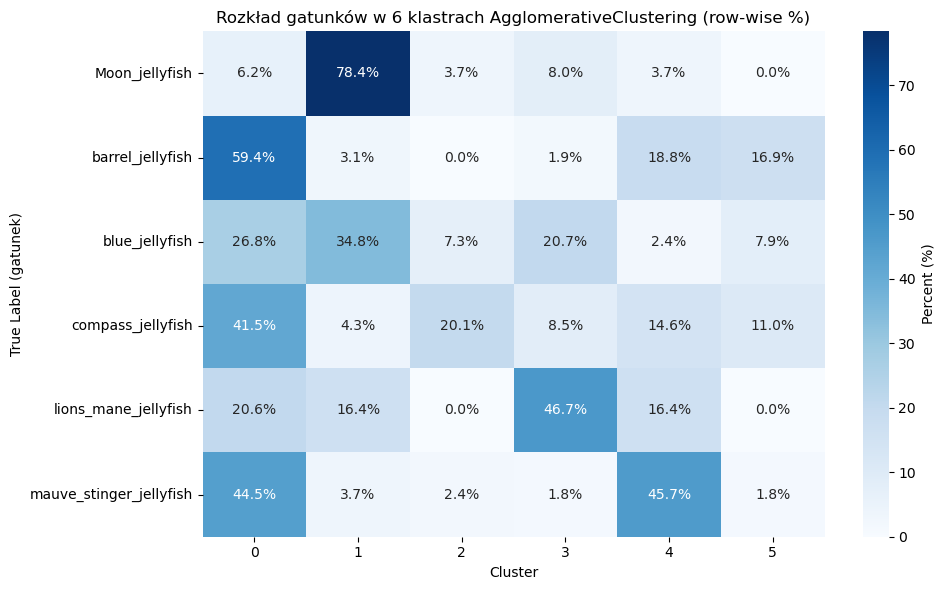

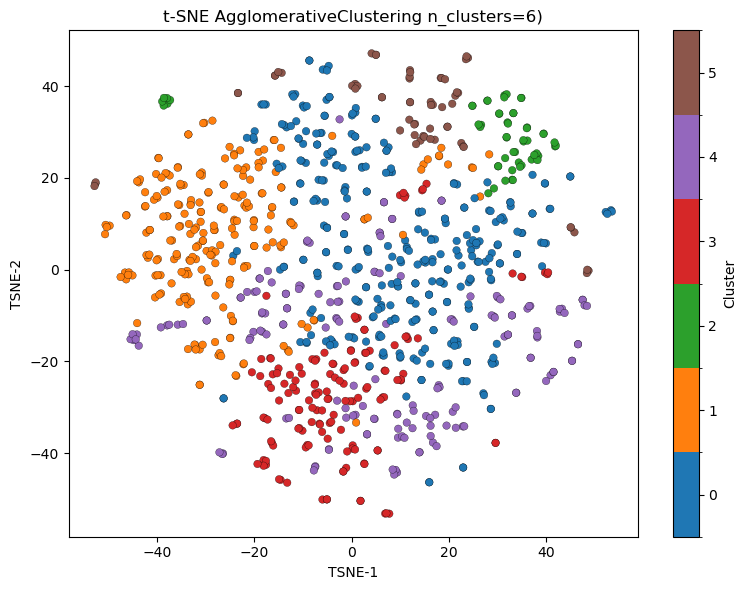

In [176]:
#Fittowanie modelu, metryki i wykresy, heatmapa przedstawia ile procent zdjęć danego gatunku znajduje się w danym klastrze
y_pred=agg.fit_predict(X_df)

metrics(df["label"],y_pred)
confusion_matrix(y_pred,"AgglomerativeClustering",df)
plot_tsne_clusters(y_pred, "AgglomerativeClustering", 6)